# Introduction

The goal of this notebook is to group our customers into distinct segments based on their purchasing behavior. By understanding who our customers are, the business can drop generic marketing and instead use targeted, personalized strategies to increase customer loyalty and maximize revenue.

## Import statements and setting style

In [1]:
import pandas as pd
import seaborn as sns
import src.helpers as hp
import src.plotting as plot
import src.rfm as r

In [2]:
pd.options.display.float_format = "{:,.2f}".format

plot.set_plot_style()

# Data Load

In [3]:
df_customers = hp.load_view("vw_customer_summary_python")

Design logic behind this view was that only successful orders (not 'canceled' or 'unavailable') should be counted towards total_spent. For the purpose of this analysis we should exclude them.

In [4]:
df_customers.dropna(inplace=True)

Currently, in the view we have customer_tenure_days defined as days between first and last purchase of customer. While it could potentially be a good metric we are dealing with a dataset where majority of customers ordered only once.

Instead, let's add recency metric, defined as days between last purchase and snapshot date (last date in dataset), for RFM analysis.

In [5]:
analysis_date = df_customers["last_purchase_date"].max() + pd.Timedelta(days=1)

df_customers["recency"] = (analysis_date - df_customers["last_purchase_date"]).dt.days

In [6]:
features = ["recency", "total_orders","total_spent"]

df_customers[features].describe()

,recency,total_orders,total_spent
count,"94,989.00","94,989.00","94,989.00"
mean,287.09,1.04,165.69
std,152.99,0.22,226.74
min,1.00,1.00,9.59
25%,163.00,1.00,63.10
50%,268.00,1.00,107.90
75%,396.00,1.00,182.94
max,772.00,17.00,"13,664.08"


In [7]:
df_customers["R_Score"] = pd.qcut(df_customers["recency"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
df_customers["F_Score"] = df_customers["total_orders"].apply(r.assign_f_score).astype(int)
df_customers["M_Score"] = pd.qcut(df_customers["total_spent"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# RFM Segments

In previous step we have calculated scores for each of RFM metric. Next step is definition of segments' names and characteristics.

We have defined below score levels to simplyfy rating:
| Level | Score |
|-------|-------|
| High | 4 - 5 |
| Mid | 3 |
| Low | 1 - 2 |

In [8]:
rfm_segments_df = pd.DataFrame.from_dict(r.RFM_SEGMENTS, orient="index").reset_index().rename(columns={"index": "Segment"})
rfm_segments_df

,Segment,R,F,M,Description,Typical Actions
0,Champions,High,High,High,Best and most valuable customers.,"Loyalty program, VIP treatment, early access."
1,Loyal Customers,"[Mid, High]",High,"[Low, Mid, High]",Frequent customers who remain relatively active.,"Personalized offers, loyalty rewards, ask for ..."
2,Cannot Lose Them,Low,High,"[Mid, High]",Previously valuable and frequent customers who...,"Personalized win-back campaign, direct contact..."
3,At Risk,Low,"[Mid, High]","[Low, Mid, High]",Previously engaged customers whose activity ha...,"Win-back offers, satisfaction survey, personal..."
4,Potential Loyalists,High,Mid,"[Low, Mid, High]",Recent customers who have already made more th...,"Loyalty invitation, personalized recommendatio..."
5,New Customers,High,Low,"[Low, Mid, High]",Recent customers with limited purchase history.,"Onboarding, product recommendations, next-orde..."
6,Needs Attention,Mid,"[Low, Mid]","[Low, Mid, High]",Customers with moderate or declining engagement.,"Relevant offers, reminders, engagement campaign."
7,Hibernating,Low,Low,"[Low, Mid, High]",Inactive customers with little purchase activity.,"Low-cost reactivation campaign, newsletter, au..."


In [9]:
df_customers["rfm_segment"] = df_customers.apply(r.assign_rfm_segment,axis=1)

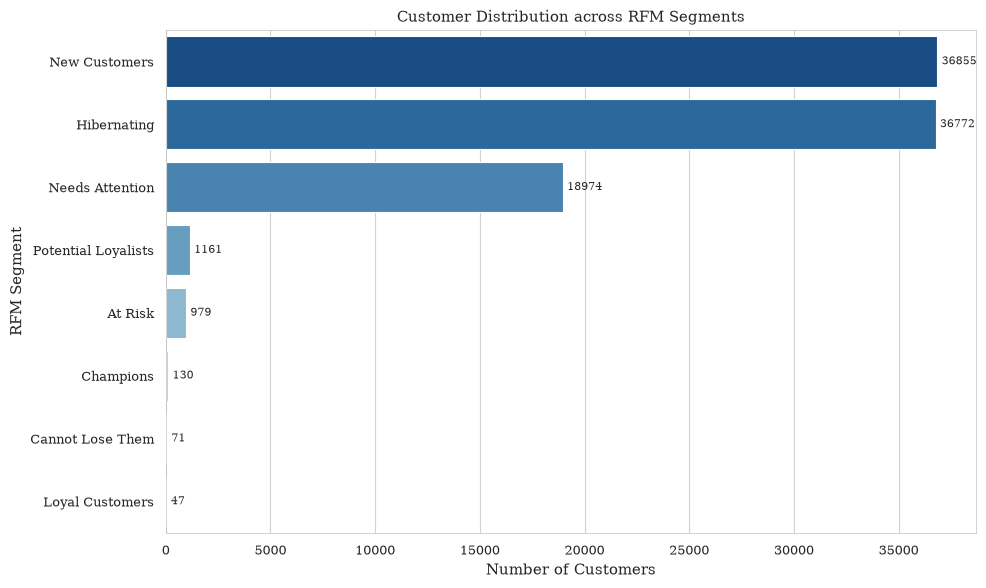

In [10]:
segment_counts = df_customers["rfm_segment"].value_counts()
total_customers = len(df_customers)

fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    ax=ax1,
    palette="Blues_r",
    hue=segment_counts.index,
    legend=False
)

plot.annotate_bars(ax=ax1, fmt="%.0f")

plot.finish_plot(
    ax1=ax1,
    title="Customer Distribution across RFM Segments",
    xlabel="Number of Customers",
    ax1_ylabel="RFM Segment",
    legend=False
)

The vast majority of the entire customer base is trapped in single-purchase segments. This is consistent with prior findings: Olist is highly effective at acquiring traffic, but struggles with customer retention.

# Segments Profiling

In [11]:
segment_profile = df_customers.groupby("rfm_segment").agg(
    customer_count=("customer_unique_id", "count"),
    avg_r_score=("R_Score", "mean"),
    avg_f_score=("F_Score", "mean"),
    avg_m_score=("M_Score", "mean"),
    total_revenue=("total_spent", "sum"),
).reset_index()

total_platform_revenue = segment_profile["total_revenue"].sum()
segment_profile["revenue_share_%"] = (segment_profile["total_revenue"] / total_platform_revenue) * 100

segment_profile = segment_profile.sort_values(by="total_revenue", ascending=False)


In [12]:
columns_to_plot = ["avg_r_score", "avg_f_score", "avg_m_score"]

heatmap_data = segment_profile.set_index("rfm_segment")[columns_to_plot]
heatmap_data = heatmap_data.rename(columns={
        "avg_r_score": "Recency",
        "avg_f_score": "Frequency",
        "avg_m_score": "Monetary"
    })

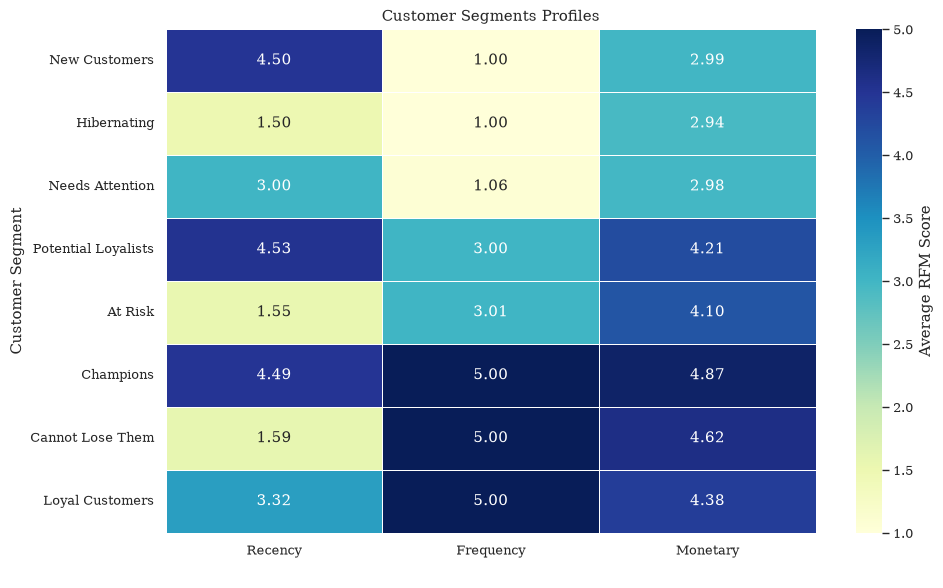

In [13]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.heatmap(
    data=heatmap_data,
    ax=ax1,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Average RFM Score"},
    annot=True,
    fmt=".2f",
    vmin=1,
    vmax=5
)

plot.finish_plot(
    ax1=ax1,
    title="Customer Segments Profiles",
    xlabel=" ",
    ax1_ylabel="Customer Segment",
    legend=False
)

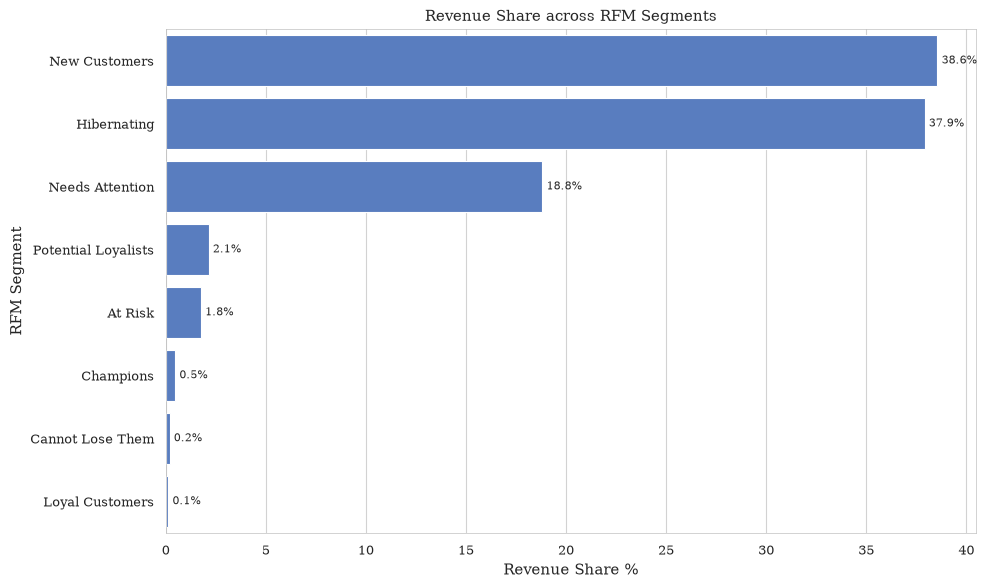

In [14]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.barplot(
    x=segment_profile["revenue_share_%"],
    y=segment_profile["rfm_segment"],
    legend=False
)

plot.annotate_bars(ax=ax1, fmt="%.1f%%")

plot.finish_plot(
    ax1=ax1,
    title="Revenue Share across RFM Segments",
    xlabel="Revenue Share %",
    ax1_ylabel="RFM Segment",
    legend=False
)

## Observations from Segment Profiling:

1. New Customers account for the largest revenue share primarily because they represent one of the largest customer groups. Converting even a small proportion into repeat buyers could therefore generate meaningful incremental revenue.
2. Potential Loyalists, At Risk, Cannot Lose Them and Needs Attention segments should be targeted to ensure conversion into loyal customer base.
3. Champions and Loyal Customers generate a relatively small share of total revenue because these segments are small. Their retention remains strategically important due to their high purchase frequency and monetary scores.

In [15]:
champions_geo = df_customers[df_customers["rfm_segment"] == "Champions"]["customer_state"].value_counts(normalize=True).head(5) * 100
print("Top states for Champions (%):")
print(champions_geo)

lost_geo = df_customers[df_customers["rfm_segment"] == "Hibernating"]["customer_state"].value_counts(normalize=True).head(5) * 100
print("\nTop states for Hibernating (%):")
print(lost_geo)

Top states for Champions (%):
customer_state
SP   46.15
RJ   14.62
MG    9.23
RS    5.38
BA    5.38
Name: proportion, dtype: float64

Top states for Hibernating (%):
customer_state
SP   38.83
RJ   13.82
MG   12.06
RS    6.04
PR    5.04
Name: proportion, dtype: float64


Champions and Hibernating customers show broadly similar geographic concentrations, with São Paulo dominating both groups. In this descriptive comparison, geography does not appear to clearly distinguish these two segments.

In [16]:
df_customers["failed_order_rate"] = (df_customers["failed_orders"] / df_customers["total_orders"])

In [17]:
failed_rate_by_segment = df_customers.groupby("rfm_segment").agg(failed_orders=("failed_orders", "sum"),total_orders=("total_orders", "sum"))

failed_rate_by_segment["failed_order_rate"] = failed_rate_by_segment["failed_orders"] / failed_rate_by_segment["total_orders"] * 100

failed_rate_by_segment.sort_values(by="failed_order_rate", ascending=False, inplace=True)


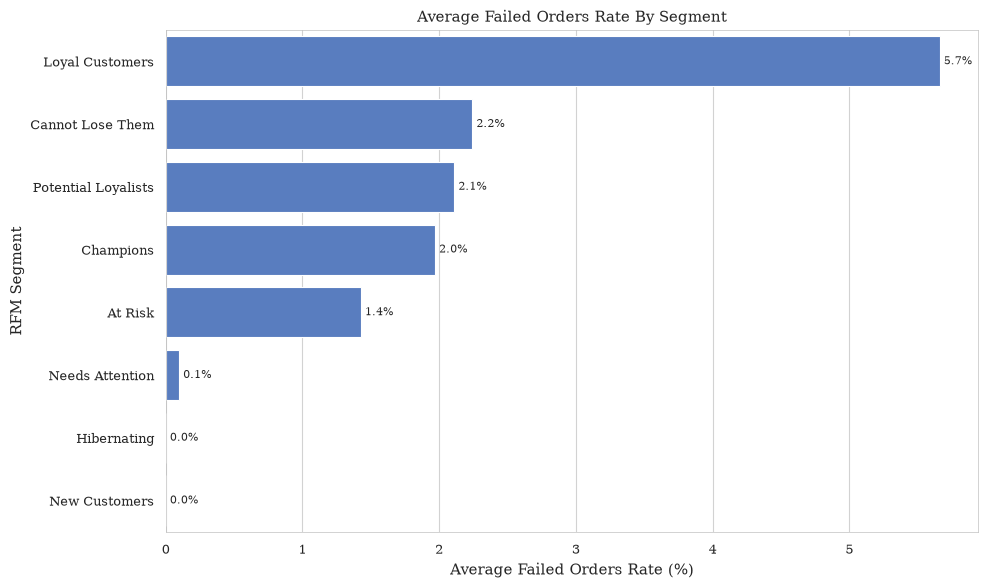

In [18]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.barplot(
    data=failed_rate_by_segment,
    x="failed_order_rate",
    y="rfm_segment",
    ax=ax1,
    legend=False
)

plot.annotate_bars(ax=ax1, fmt="%.1f%%")

plot.finish_plot(
    ax1=ax1,
    title="Average Failed Orders Rate By Segment",
    xlabel="Average Failed Orders Rate (%)",
    ax1_ylabel="RFM Segment",
    legend=False
)

Failed-order rates vary across RFM segments, although differences should be interpreted cautiously because segment sizes and purchase frequencies differ substantially. Multi-purchase segments show a clear correlation between higher historical order volume and experienced order failures, while one-timers remain at zero due to the initial filtering.

# Executive Summary

## Key Findings
* **One-Time Purchase Model:** The Olist platform is heavily dependent on customer acquisition rather than retention. Majority of the customer base consists of one-time buyers who are currently inactive or hibernating.
* **High-Value Newcomers:** First-time buyers with large order values represent the highest low-hanging fruit. They are fresh, have capital, and offer the highest ROI for immediate second-purchase conversion campaigns.
* **Geography is Neutral:** The geographic distribution of customers is almost identical across all segments, heavily dominated by São Paulo (SP). Location is not a driving factor for loyalty or churn.
* **Friction Drives Churn:** Loyal Customers show the highest rate of failed orders. Delivery issues are directly correlated with losing previously loyal multi-purchase customers. Olist should ensure actions to lower the chances of losing customers from that segment.


## Strategic Recommendations
* **Target High-Value Newcomers:** Implement an automated onboarding sequence with exclusive vouchers or cashback within 14 days of their first large purchase to lock in a second order.
* **Reduce Wasteful Marketing Spend:** Consider testing lower-cost reactivation channels for Hibernating customers before investing in paid retargeting.
* **Fix Operational Friction:** Coordinate with the product and logistics teams to investigate failed orders. Resolving technical and delivery issues is critical to preventing valuable multi-purchase customers from churning.

# Customer Summary File for PowerBi

In [19]:
df_customers

,customer_unique_id,customer_city,customer_state,first_purchase_date,first_purchase_month,last_purchase_date,customer_tenure_days,total_orders,failed_orders,total_spent,avg_order_value,recency,R_Score,F_Score,M_Score,rfm_segment,failed_order_rate
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,2018-05-10 10:56:27,2018-05-01,2018-05-10 10:56:27,0,1,0,141.90,141.90,160,4,1,4,New Customers,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,2018-05-07 11:11:27,2018-05-01,2018-05-07 11:11:27,0,1,0,27.19,27.19,163,4,1,1,New Customers,0.00
2,0000f46a3911fa3c0805444483337064,sao jose,SC,2017-03-10 21:05:03,2017-03-01,2017-03-10 21:05:03,0,1,0,86.22,86.22,585,1,1,2,Hibernating,0.00
3,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,2017-10-12 20:29:41,2017-10-01,2017-10-12 20:29:41,0,1,0,43.62,43.62,369,2,1,1,Hibernating,0.00
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,2017-11-14 19:45:42,2017-11-01,2017-11-14 19:45:42,0,1,0,196.89,196.89,337,2,1,4,Hibernating,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,sanharo,PE,2017-06-08 21:00:36,2017-06-01,2017-06-08 21:00:36,0,1,0,"2,067.42","2,067.42",495,1,1,5,Hibernating,0.00
96092,fffea47cd6d3cc0a88bd621562a9d061,feira de santana,BA,2017-12-10 20:07:56,2017-12-01,2017-12-10 20:07:56,0,1,0,84.58,84.58,311,3,1,2,Needs Attention,0.00
96093,ffff371b4d645b6ecea244b27531430a,sinop,MT,2017-02-07 15:49:16,2017-02-01,2017-02-07 15:49:16,0,1,0,112.46,112.46,617,1,1,3,Hibernating,0.00
96094,ffff5962728ec6157033ef9805bacc48,bom jesus do norte,ES,2018-05-02 15:17:41,2018-05-01,2018-05-02 15:17:41,0,1,0,133.69,133.69,168,4,1,4,New Customers,0.00


In [20]:
df_rfm_powerbi = df_customers.rename(columns={
    "R_Score": "r_score",
    "F_Score": "f_score",
    "M_Score": "m_score",
    }).copy()

assert df_rfm_powerbi["customer_unique_id"].is_unique
assert df_rfm_powerbi["rfm_segment"].notna().all()
assert not (df_rfm_powerbi["rfm_segment"] == "Other").any()



In [21]:
state_list = pd.DataFrame(df_rfm_powerbi["customer_state"].unique())

In [22]:
state_list.to_csv("../data/state_list.csv", index=False)

In [23]:
df_rfm_powerbi.to_csv("../data/customer_summary_rfm.csv", index=False)